#Analisis Data Food Delivery Jakarta
###**Oleh:** Faiz
###**Tanggal:** 21 April 2026

---
# Latar Belakang
Sebagai data analyst magang di startup food delivery,saya menganalisis 50 data orderan selama satu minggu untuk memberikan rekomendasi ke tim bisnis.

## Tujuan Analisis
1. Mengetahui performa resto
2. Memahami behavior customer
3. Mengidentifikasi masalah kualitas layanan
4. Memberikan rekomendasi bisnis berbasis data

**1. Import & Load Data**

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_food_delivery.csv")

**2. Eksplorasi Data**

In [100]:
print(df.head())
print(df.shape)
print(df.describe())

   order_id     tanggal jam_order              resto kategori_resto  \
0      1001  2026-01-02     11:30  Ayam Geprek Juara        Makanan   
1      1002  2026-01-02     12:15      Kopi Kenangan        Minuman   
2      1003  2026-01-02     12:45      Burger Bangor        Makanan   
3      1004  2026-01-02     13:00  Ayam Geprek Juara        Makanan   
4      1005  2026-01-02     18:30        Sushi Murah        Makanan   

               menu  harga  rating  waktu_antar_menit metode_bayar  \
0   Geprek Original  18000     4.5                 25        GoPay   
1         Americano  22000     4.8                 15          OVO   
2     Cheese Burger  35000     4.2                 30         Cash   
3  Geprek Mozarella  25000     4.6                 28        GoPay   
4       Salmon Roll  45000     4.0                 40          OVO   

              area  
0  Jakarta Selatan  
1  Jakarta Selatan  
2    Jakarta Barat  
3  Jakarta Selatan  
4    Jakarta Pusat  
(50, 11)
         order_id



> Dataset ini berisi 50 order dari 8 resto selama 7 hari
(2-7 Januari 2026). Rata-rata harga per order Rp 29.120
dengan rating keseluruhan 4.43 dari 5.0.



In [101]:
df["harga"].sum()

np.int64(1456000)

In [102]:
df["harga"].mean()

np.float64(29120.0)

In [103]:
df["rating"].mean()

np.float64(4.425999999999999)

**3. Insight**

## Analisis Resto

In [104]:
df.groupby("resto")["order_id"].count()

,order_id
resto,
Ayam Geprek Juara,7
Burger Bangor,6
Es Teh Solo,5
Kopi Kenangan,10
Martabak San,5
Mie Gacoan,6
Salad Nyonya,5
Sushi Murah,6


> Kopi Kenangan mendominasi dengan 10 order, hampir 2x lipat dari resto lain(5-7)

In [105]:
df.groupby("resto")["rating"].mean()

,rating
resto,
Ayam Geprek Juara,4.514286
Burger Bangor,4.300000
Es Teh Solo,4.080000
Kopi Kenangan,4.780000
Martabak San,4.820000
Mie Gacoan,4.250000
Salad Nyonya,4.480000
Sushi Murah,3.950000




> Martabak San memiliki rata-rata rating tertinggi (4.82)
> diikuti Kopi Kenangan (4.78), sementara Sushi Murah
> berada di posisi terendah (3.95). Rating rendah Sushi
> Murah kemungkinan berkaitan dengan waktu antarnya yang
> paling lama di antara semua resto.



>

In [106]:
df.groupby("resto")["waktu_antar_menit"].mean()

,waktu_antar_menit
resto,
Ayam Geprek Juara,27.142857
Burger Bangor,31.500000
Es Teh Solo,10.400000
Kopi Kenangan,15.300000
Martabak San,27.200000
Mie Gacoan,20.000000
Salad Nyonya,20.400000
Sushi Murah,41.500000


>Di sini waktu antar memang berbeda-beda sesuai makanan/minuman apa yang dibuat, contoh Es Teh Solo itu minuman yang mudah diproses sehingga waktu antarnya hanya membutuhkan 10 menit. Sedangkan Sushi Murah itu makanan yang membutuhkan waktu ekstra untuk diproses sehingga waktu antarnya yang paling lama.

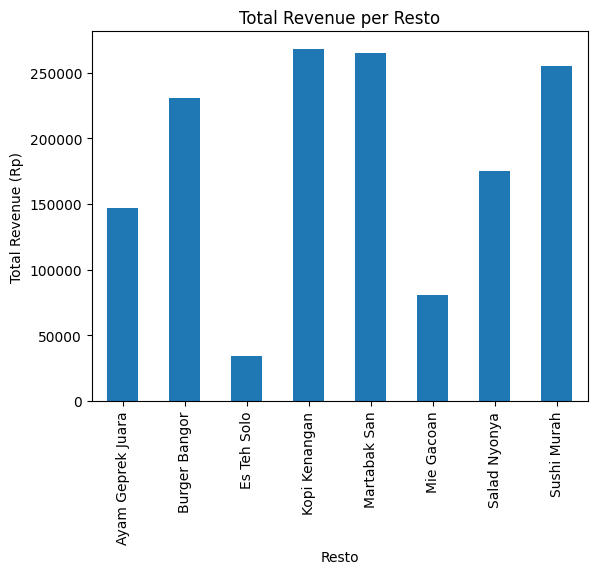

In [107]:
data_resto = df.groupby("resto")["harga"].sum()
data_resto.plot(kind="bar")
plt.title("Total Revenue per Resto")
plt.xlabel("Resto")
plt.ylabel("Total Revenue (Rp)")
plt.show()

> Dari chart di atas, terlihat bahwa Kopi Kenangan
> menyumbang revenue terbesar. Hal ini kemungkinan
> karena produk kopi merupakan kebutuhan harian
> karyawan kantoran.

## Analisis Customer Behavior

In [108]:
df.groupby("metode_bayar")["order_id"].count()

,order_id
metode_bayar,
Cash,16
GoPay,19
OVO,15




> GoPay menduduki sebagai metode pembayaran paling sering digunakan



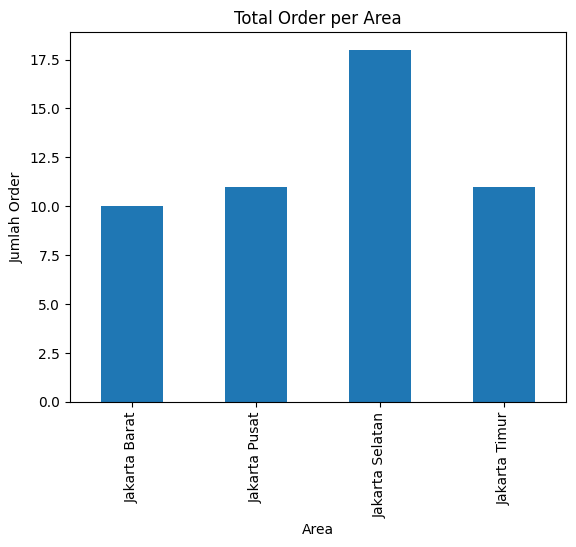

In [109]:
data_order_jakarta = df.groupby("area")["order_id"].count()
data_order_jakarta.plot(kind="bar")
plt.title("Total Order per Area")
plt.xlabel("Area")
plt.ylabel("Jumlah Order")
plt.show()



> Dari analisis groupby area, Jakarta Selatan menjadi area
dengan jumlah order tertinggi. Hal ini kemungkinan karena
Jaksel merupakan area yang padat penduduk, khususnya
karyawan kantoran yang sering memesan makanan dan minuman
saat jam kerja maupun setelah pulang kantor.

> Sementara itu, area seperti Jakarta Pusat dan Jakarta Timur
memiliki jumlah order yang lebih rendah. Ini bisa menjadi
opportunity, misalnya dengan membuat iklan di TikTok atau
Instagram yang menampilkan promo khusus di area tersebut,
lengkap dengan kode promo per area agar lebih targeted.



In [110]:
df.groupby("area")["harga"].mean()

,harga
area,
Jakarta Barat,32500.000000
Jakarta Pusat,47272.727273
Jakarta Selatan,27555.555556
Jakarta Timur,10454.545455


> Jakarta Pusat memiliki rata-rata harga order tertinggi
> (Rp 47.272) karena didominasi oleh resto dengan menu
> premium seperti Martabak San dan Sushi Murah. Sementara
> Jakarta Timur punya rata-rata terendah (Rp 10.454) karena
> mayoritas order-nya berasal dari Es Teh Solo dan Mie Gacoan
> yang memang harganya terjangkau.
>
> Insight ini menunjukkan bahwa setiap area punya segmen
> customer yang berbeda. Jakarta Pusat cocok untuk push
> menu premium, sedangkan Jakarta Timur lebih potensial
> untuk strategi volume (banyak order dengan harga murah).

## Analisis Kualitas Layanan

In [111]:
df["waktu_antar_menit"].mean()

np.float64(23.82)

In [112]:
print(df[df["waktu_antar_menit"] > 35][["resto", "menu", "waktu_antar_menit"]])
print(len(df[df["waktu_antar_menit"] > 35]))

          resto         menu  waktu_antar_menit
4   Sushi Murah  Salmon Roll                 40
14  Sushi Murah    Tuna Roll                 45
23  Sushi Murah  Salmon Roll                 42
31  Sushi Murah    Tuna Roll                 38
39  Sushi Murah  Salmon Roll                 40
47  Sushi Murah    Tuna Roll                 44
6


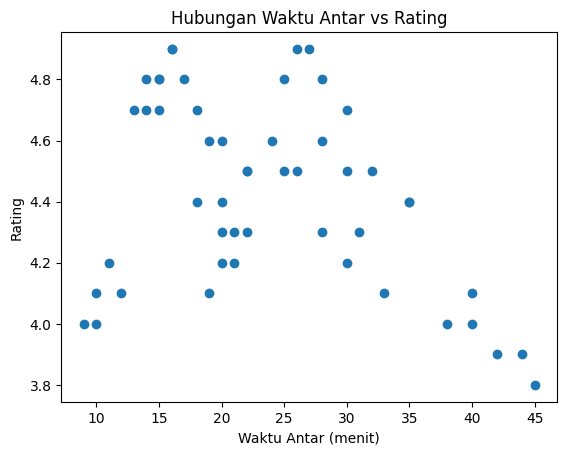

In [113]:
plt.scatter(df["waktu_antar_menit"], df["rating"])
plt.title("Hubungan Waktu Antar vs Rating")
plt.xlabel("Waktu Antar (menit)")
plt.ylabel("Rating")
plt.show()

>Dari scatter plot waktu antar vs rating, tidak terlihat
korelasi positif maupun negatif yang kuat. Namun ada
kecenderungan menarik: pada waktu antar tercepat (sekitar
10 menit), rating berada di kisaran 4.0. Rating justru
mencapai puncaknya (4.7-4.9) pada waktu antar 15-30 menit.
Setelah itu, rating cenderung menurun di waktu antar yang
lebih lama, dengan titik terendah 3.8 di waktu 44-45 menit.

>Ini menunjukkan bahwa customer tidak terlalu peduli apakah
pesanan datang sangat cepat, selama masih dalam rentang
wajar (15-30 menit). Tapi begitu waktu antar melewati
35 menit, kepuasan customer mulai turun signifikan.

>Rekomendasi: fokus utama bukan mempercepat semua
pengantaran, tapi memastikan tidak ada order yang melewati
batas 35 menit, terutama dari Sushi Murah yang sering
muncul di daftar order lambat.

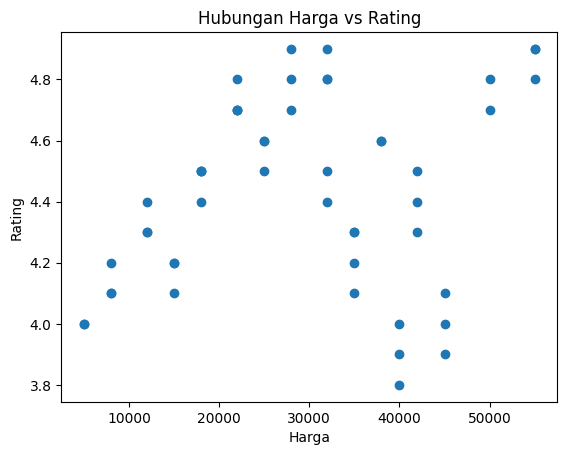

In [114]:
plt.scatter(df["harga"], df["rating"])
plt.title("Hubungan Harga vs Rating")
plt.xlabel("Harga")
plt.ylabel("Rating")
plt.show()

>Dari scatter plot harga vs rating, terlihat bahwa tidak ada
korelasi yang kuat antara harga menu dengan rating customer.
Menu dengan harga murah seperti Es Teh (Rp 5.000-8.000)
tetap mendapat rating sekitar 4.0-4.2, sementara menu
termahal seperti Martabak Coklat (Rp 55.000) justru
mendapat rating tertinggi di kisaran 4.8-4.9.

>Namun ada catatan menarik, menu di rentang harga menengah
(Rp 25.000-45.000) memiliki rating yang cukup bervariasi,
dari 3.8 hingga 4.6. Ini menunjukkan bahwa harga bukan
faktor utama kepuasan customer, melainkan yang lebih berpengaruh
kemungkinan adalah kualitas rasa dan kecepatan pengantaran.

>Rekomendasi: resto tidak perlu menurunkan harga untuk
mengejar rating tinggi. Lebih baik fokus ke konsistensi
kualitas makanan dan menjaga waktu antar di bawah 35 menit.

**4. Kesimpulan & Rekomendasi**
1. Improve waktu antar Sushi Murah
Alasan: Sushi Murah punya rata-rata waktu antar paling
lama dan sering muncul di daftar order lambat (>35 menit).
Rating mereka juga cenderung lebih rendah. Kalau waktu
antarnya diperbaiki, rating bisa naik.
2. Buat paket makan siang untuk karyawan
Kopi Kenangan mendominasi revenue karena produknya
menjadi kebutuhan harian karyawan dengan harga terjangkau.
Resto makanan lain bisa meniru strategi ini dengan membuat
paket makan siang di kisaran Rp 20.000-30.000 yang
menargetkan karyawan saat jam istirahat. Ini bisa
meningkatkan jumlah order resto lain yang saat ini hanya
berkisar 5-7 order per minggu.
3. Boost order di area yang masih sepi
Jakarta Selatan menyumbang order terbanyak, sementara
Jakarta Pusat dan Jakarta Timur masih rendah. Strategi
yang disarankan: buat campaign di TikTok dan Instagram
dengan kode promo khusus per area, dikombinasikan dengan
cashback GoPay (metode bayar paling populer dengan 19
dari 50 order) untuk memaksimalkan konversi di area
yang belum optimal.